<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Grupo_Mexico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 8.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math
from pmdarima.arima import auto_arima

#Grupo México

In [4]:
#Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01')

/tmp/ipykernel_2596/2329736698.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [5]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [6]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Análisis de la serie

##Medias Móviles

###Media Móvil Simple

In [7]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

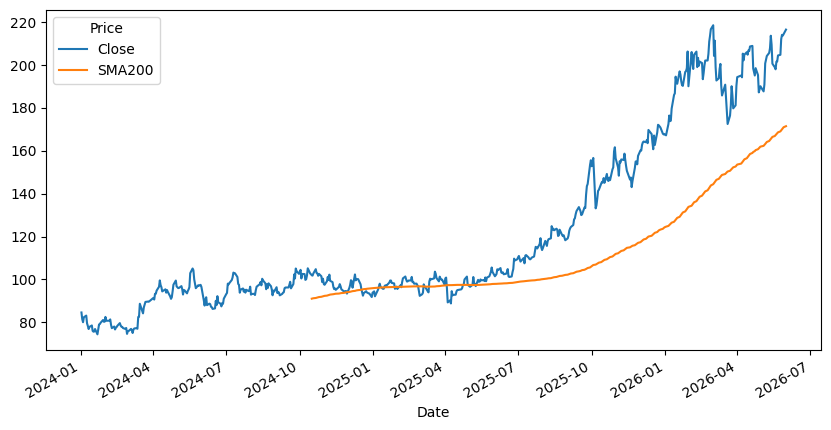

In [8]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [9]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [10]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

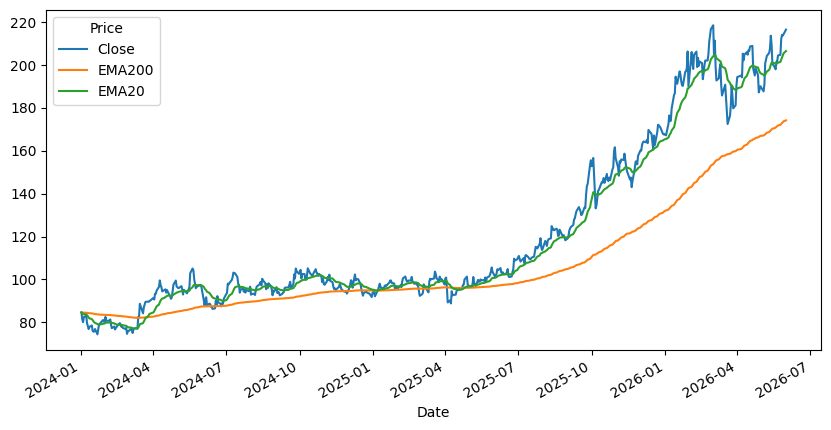

In [11]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

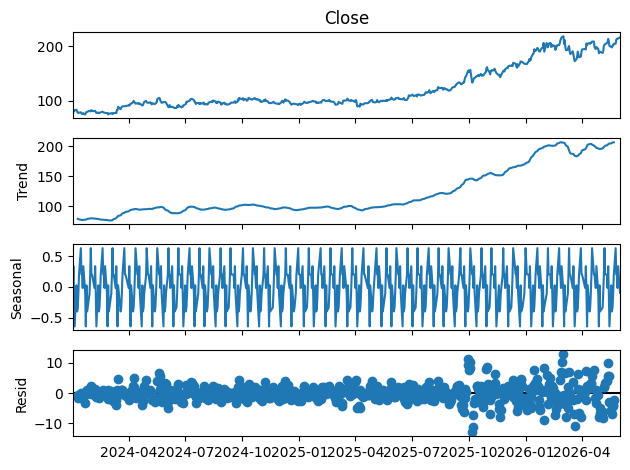

In [12]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

###Modelo Multiplicativo

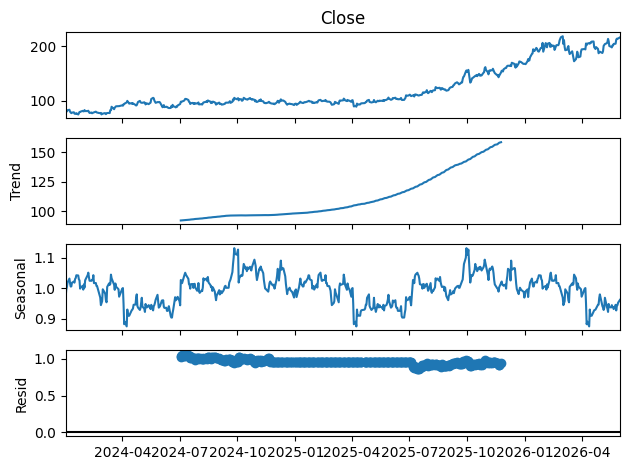

In [13]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()

In [14]:
# Seleccionar la columna de cierre y eliminar valores nulos
series = df['Close'].dropna()

In [15]:
# 2. Configurar y ejecutar la descomposición STL
# period: longitud de la estacionalidad. Para datos diarios, usualmente 365.
# robust=True ayuda a reducir la influencia de valores atípicos.
stl = STL(series, period=365, robust=True)
result = stl.fit()

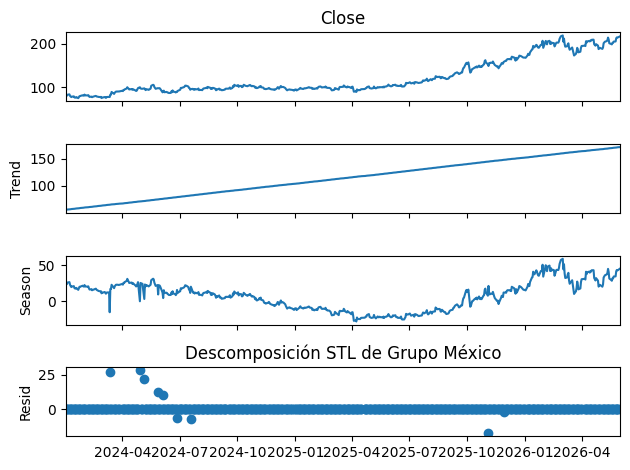

In [16]:
# 3. Visualizar los componentes
result.plot()
plt.title(f"Descomposición STL de Grupo México")
plt.tight_layout()
plt.show()

#Volatilidad

##Desviación Estándar

In [17]:
#Obtener datos
precios = df['Close']

In [18]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
                ...   
2026-05-26    0.035155
2026-05-27    0.009225
2026-05-28   -0.001717
2026-05-29    0.003225
2026-06-01    0.009891
Name: Rendimientos_Log, Length: 603, dtype: float64


In [19]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-05-26    0.035155
2026-05-27    0.009225
2026-05-28   -0.001717
2026-05-29    0.003225
2026-06-01    0.009891
Name: Rendimientos_Log, Length: 602, dtype: float64


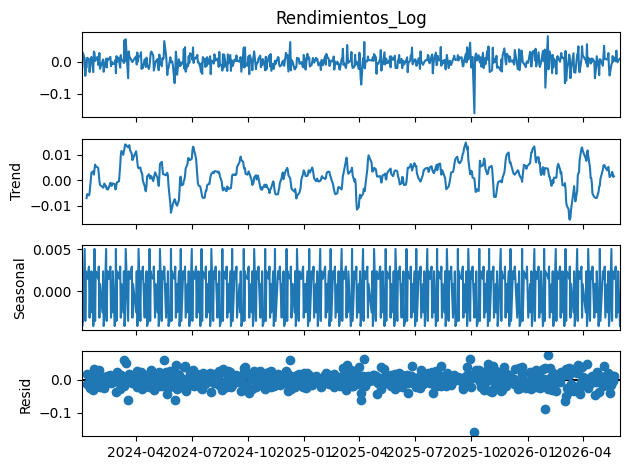

In [20]:
# Descomponer
result = seasonal_decompose(df['Rendimientos_Log'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

In [21]:
# 2. Configurar y ejecutar la descomposición STL
# period: longitud de la estacionalidad. Para datos diarios, usualmente 365.
# robust=True ayuda a reducir la influencia de valores atípicos.
stl = STL(df['Rendimientos_Log'], period=365, robust=True)
result = stl.fit()

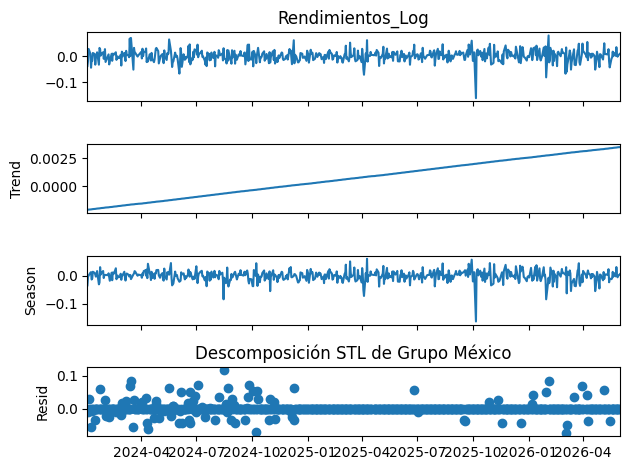

In [22]:
# 3. Visualizar los componentes
result.plot()
plt.title(f"Descomposición STL de Grupo México")
plt.tight_layout()
plt.show()

In [23]:
#Calcular la desviación estándar de los rendimientos (Volatilidad Diaria)
volatilidad_diaria = df['Rendimientos_Log'].std()

In [24]:
#Anualizar la volatilidad (multiplicando por la raíz cuadrada de 252 días hábiles al año)
volatilidad_anual = volatilidad_diaria * np.sqrt(252)

In [25]:
Volatilidad_diaria_porcentaje = volatilidad_diaria * 100
Volatilidad_anual_porcentaje = volatilidad_anual * 100

In [26]:
print(f"Volatilidad diaria: {volatilidad_diaria:.4f} = {Volatilidad_diaria_porcentaje:.4f} %")
print(f"Volatilidad anualizada: {volatilidad_anual:.4f} = {Volatilidad_anual_porcentaje:.4f} %")

Volatilidad diaria: 0.0222 = 2.2235 %
Volatilidad anualizada: 0.3530 = 35.2971 %


##Average True Range

In [27]:
#Calcular los 3 componentes del True Range (TR)
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift(1))
low_close = np.abs(df['Low'] - df['Close'].shift(1))

In [28]:
print(high_low)

Date
2024-01-03    3.811026
2024-01-04    2.643276
2024-01-05    6.381882
2024-01-08    2.570863
2024-01-09    4.200277
                ...   
2026-05-26    8.921092
2026-05-27    4.912053
2026-05-28    7.839436
2026-05-29    8.860001
2026-06-01    7.479996
Length: 602, dtype: float64


In [29]:
print(high_close)

Date
2024-01-03         NaN
2024-01-04    0.117674
2024-01-05    6.046956
2024-01-08    0.887126
2024-01-09    0.253476
                ...   
2026-05-26    7.680666
2026-05-27    2.788468
2026-05-28    1.369413
2026-05-29    3.400009
2026-06-01    2.210007
Length: 602, dtype: float64


In [30]:
print(low_close)

Date
2024-01-03         NaN
2024-01-04    2.525602
2024-01-05    0.334926
2024-01-08    1.683737
2024-01-09    3.946801
                ...   
2026-05-26    1.240426
2026-05-27    2.123585
2026-05-28    6.470023
2026-05-29    5.459991
2026-06-01    5.269989
Length: 602, dtype: float64


In [31]:
#Unir y obtener el máximo de los 3 para cada día
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = ranges.max(axis=1)

In [32]:
print(true_range)

Date
2024-01-03    3.811026
2024-01-04    2.643276
2024-01-05    6.381882
2024-01-08    2.570863
2024-01-09    4.200277
                ...   
2026-05-26    8.921092
2026-05-27    4.912053
2026-05-28    7.839436
2026-05-29    8.860001
2026-06-01    7.479996
Length: 602, dtype: float64


In [33]:
#Calcular el ATR (suavizado clásico de Wilder, n=14)
atr_period = 14
atr = true_range.copy()

In [34]:
#El primer ATR es la media simple de los primeros 14 días
atr.iloc[atr_period-1] = true_range.iloc[:atr_period].mean()

In [35]:
#Iterar para aplicar la fórmula suavizada
for i in range(atr_period, len(true_range)):
    atr.iloc[i] = (atr.iloc[i-1] * (atr_period - 1) + true_range.iloc[i]) / atr_period

df['ATR_Calculado'] = atr
print(df[['High', 'Low', 'Close', 'ATR_Calculado']].tail())

Price             High         Low       Close  ATR_Calculado
Date                                                         
2026-05-26  212.359576  203.438483  212.002335       7.351460
2026-05-27  214.790803  209.878750  213.967163       7.177217
2026-05-28  215.336576  207.497140  213.599991       7.224518
2026-05-29  217.000000  208.139999  214.289993       7.341338
2026-06-01  216.500000  209.020004  216.419998       7.351242


In [36]:
#ATR diario
atr_diario = atr.mean()
print(f"ATR diario: {atr_diario:.4f}")

ATR diario: 4.1887


In [37]:
#ATR Anualizado
atr_anualizado = atr.mean() * np.sqrt(252)
print(f"ATR anualizado: {atr_anualizado:.4f}")

ATR anualizado: 66.4934


#Parámetros (p,d,q)

##Precios Diferenciados

###Serie Estacionaria


In [38]:
#Obtener datos
precios = df['Close']

In [39]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [40]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: 0.5079
Valor p: 0.9851
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.9851110449766849)

####Diferenciando

In [41]:
# Calcular la primera diferencia del precio de cierre (columna 'Close')
differenced_prices = precios.diff().dropna()

In [42]:
# Mostrar los primeros elementos de la serie diferenciada
print(differenced_prices.head())

Date
2024-01-04   -1.412170
2024-01-05    2.308350
2024-01-08    0.778496
2024-01-09   -3.611862
2024-01-10   -1.213020
Name: Close, dtype: float64


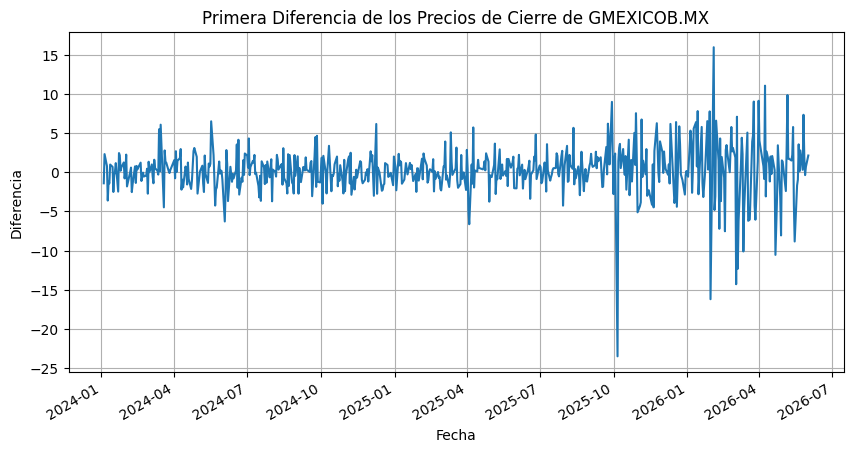

In [43]:
# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
differenced_prices.plot()
plt.title(f'Primera Diferencia de los Precios de Cierre de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

In [44]:
# Ejecutar prueba en serie diferenciada
probar_estacionariedad(differenced_prices, "Serie diferenciada")


--- Prueba ADF para: Serie diferenciada ---
Estadístico de Dickey-Fuller: -27.0404
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

###Función de Autocorrelación

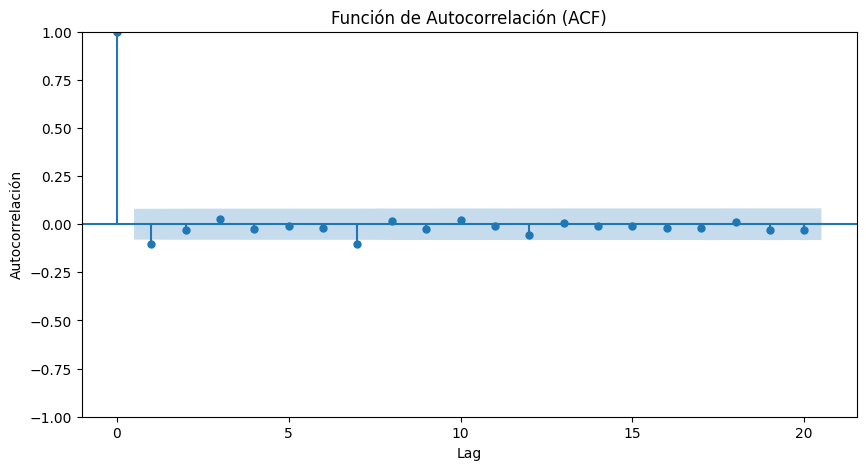

In [45]:
#Graficar la ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(differenced_prices, lags=20, ax=ax) # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial (PACF)

<Figure size 1000x500 with 0 Axes>

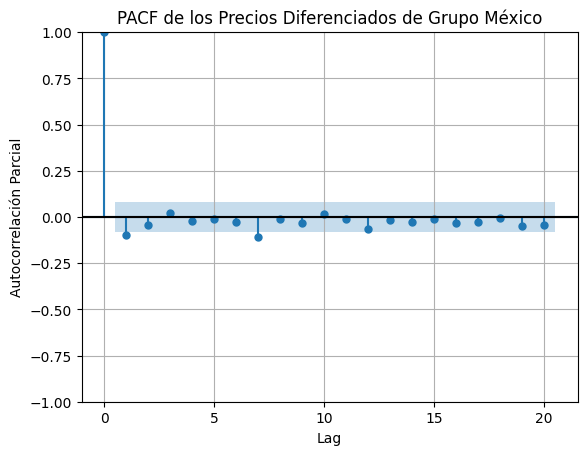

In [46]:
#Graficar la PACF
plt.figure(figsize=(10, 5))
plot_pacf(differenced_prices, lags=20, method='ywm') # method='ywm' es Yule-Walker modificado
plt.title('PACF de los Precios Diferenciados de Grupo México')
plt.xlabel('Lag')
plt.ylabel('Autocorrelación Parcial')
plt.axhline(y=0, color='k', linestyle='-')
plt.grid(True)
plt.show()

##Rendimientos Logarítmicos

In [47]:
#Cargar datos y calcular rendimientos logarítmicos
df['log_Close'] = np.log(df['Close'])

In [48]:
print(df['log_Close'])

Date
2024-01-03    4.400357
2024-01-04    4.382873
2024-01-05    4.411296
2024-01-08    4.420702
2024-01-09    4.376295
                ...   
2026-05-26    5.356597
2026-05-27    5.365823
2026-05-28    5.364105
2026-05-29    5.367330
2026-06-01    5.377221
Name: log_Close, Length: 602, dtype: float64


In [49]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada)
probar_estacionariedad(df['log_Close'], "Retornos Logarítmicos")


--- Prueba ADF para: Retornos Logarítmicos ---
Estadístico de Dickey-Fuller: 0.0558
Valor p: 0.9629
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.9629111227757011)

###Estacionariedad

In [50]:
df['rendimiento_log'] = df['log_Close'].diff().dropna()

In [51]:
print(df['rendimiento_log'])

Date
2024-01-03         NaN
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-05-26    0.035155
2026-05-27    0.009225
2026-05-28   -0.001717
2026-05-29    0.003225
2026-06-01    0.009891
Name: rendimiento_log, Length: 602, dtype: float64


In [52]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada)
probar_estacionariedad(df['rendimiento_log'], "Retornos Logarítmicos Diferenciados")


--- Prueba ADF para: Retornos Logarítmicos Diferenciados ---
Estadístico de Dickey-Fuller: -26.8137
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

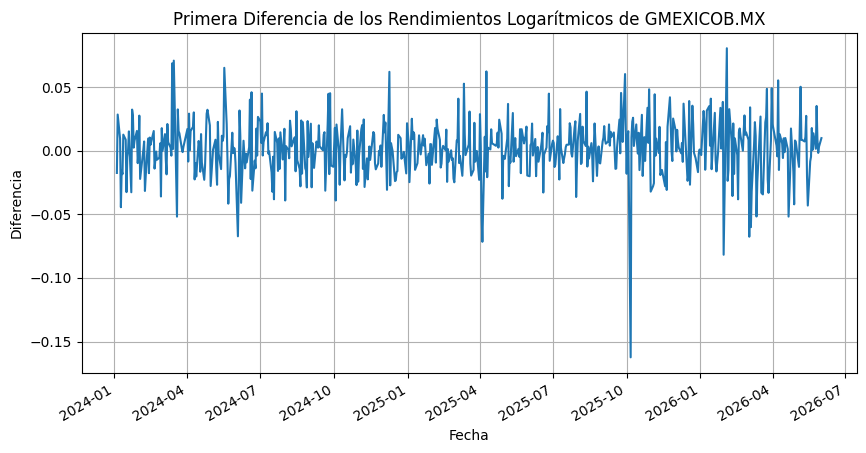

In [53]:
# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
df['rendimiento_log'].plot()
plt.title(f'Primera Diferencia de los Rendimientos Logarítmicos de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

###Función de Autocorrelación

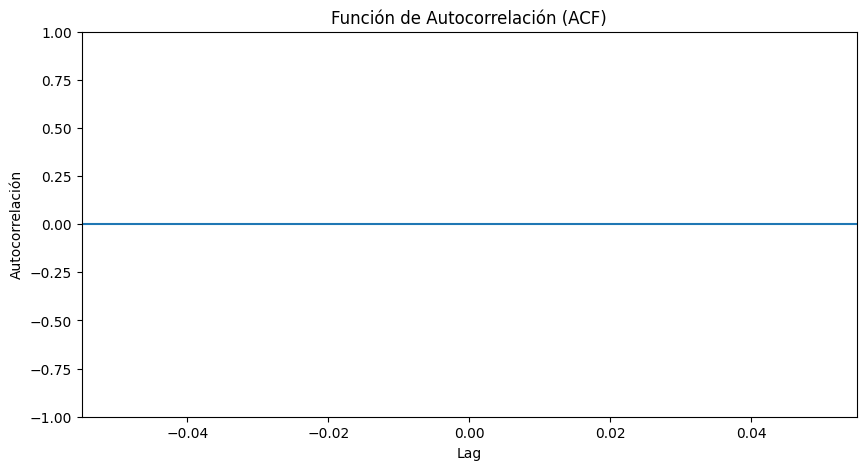

In [54]:
#Gráfica ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(df['rendimiento_log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial

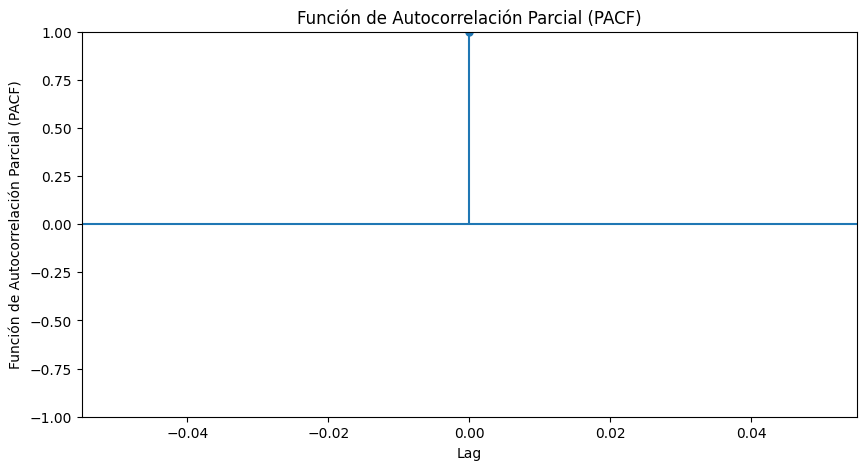

In [55]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(df['rendimiento_log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Función de Autocorrelación Parcial (PACF)")
ax.set_title("Función de Autocorrelación Parcial (PACF)")
plt.show()

#ARIMA

In [56]:
# Fit the ARIMA model
# Initial ARIMA Model parameters
p, d, q = 0,1,0
model = ARIMA(df['rendimiento_log'], order=(p, d, q))
model_fit = model.fit()
model_summary = model_fit.summary()
model_summary

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        rendimiento_log   No. Observations:                  602
Model:                 ARIMA(0, 1, 0)   Log Likelihood                1191.563
Date:                Mon, 01 Jun 2026   AIC                          -2381.127
Time:                        16:22:13   BIC                          -2376.728
Sample:                             0   HQIC                         -2379.414
                                - 602                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0011   3.66e-05     29.377      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                 173.19   Jarque-Bera (JB):               354.66
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.48   Skew:                            -0.02
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

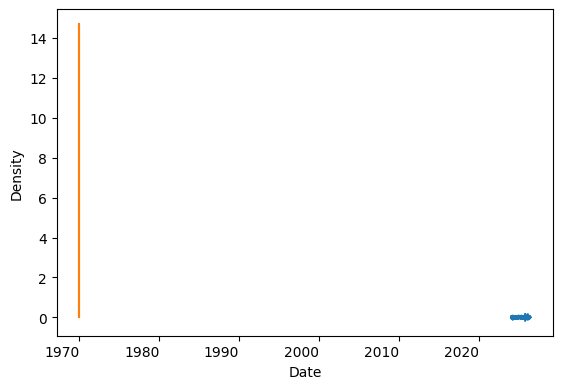

In [57]:
# plot residual errors
residuals = model_fit.resid
residuals.plot()
residuals.plot(kind='kde')
plt.show()

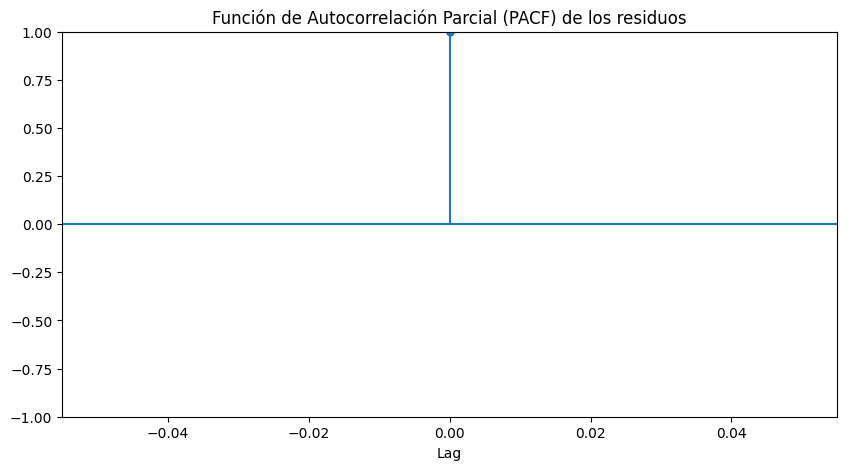

In [67]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(residuals, lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_title("Función de Autocorrelación Parcial (PACF) de los residuos")
plt.show()

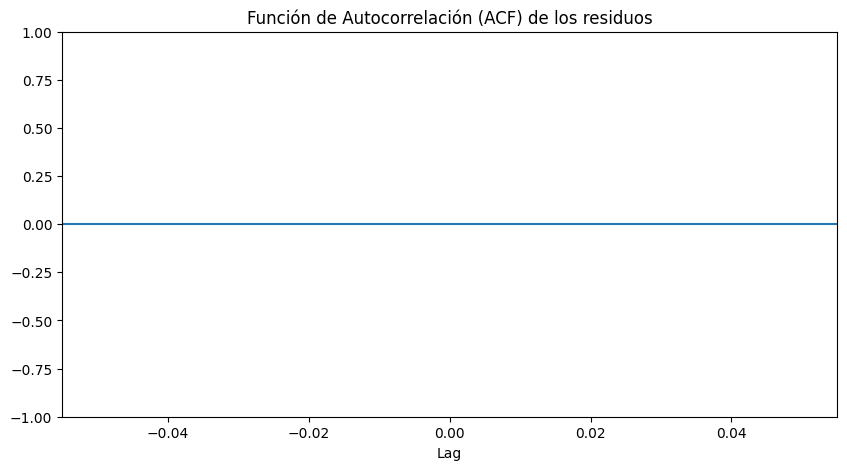

In [68]:
#Graficar la ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(residuals, lags=20, ax=ax) # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_title("Función de Autocorrelación (ACF) de los residuos")
plt.show()

In [69]:
# 2. División de datos en entrenamiento y prueba
train_size = int(len(series) * 0.8)
train, test = series.iloc[:train_size], series.iloc[train_size:]

In [70]:
# 3. Ajustar modelo ARIMA(0,1,0)
# order=(p, d, q) -> (0, 1, 0) significa:
# p=0 (sin término autorregresivo), d=1 (diferenciación para estacionariedad), q=0 (sin término de media móvil)
model = ARIMA(train, order=(0, 1, 0))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [72]:
# 4. Generar predicciones para el conjunto de prueba
# forecast(steps=n) predice los siguientes n pasos
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [73]:
# 5. Evaluación y Visualización
rmse = math.sqrt(mean_squared_error(test, forecast))
print(f"RMSE del modelo ARIMA(0,1,0): {rmse:.4f}")

RMSE del modelo ARIMA(0,1,0): 35.3020


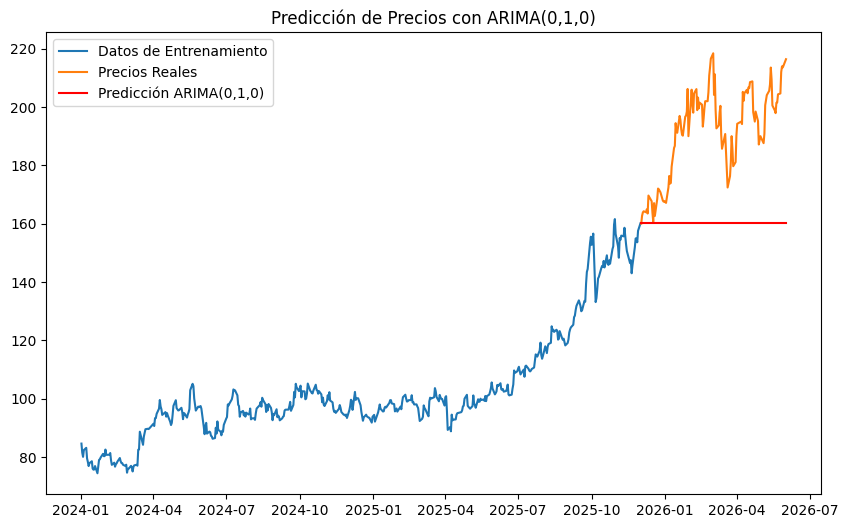

In [74]:
plt.figure(figsize=(10, 6))
plt.plot(train.index, train, label='Datos de Entrenamiento')
plt.plot(test.index, test, label='Precios Reales')
plt.plot(test.index, forecast, label='Predicción ARIMA(0,1,0)', color='red')
plt.legend()
plt.title('Predicción de Precios con ARIMA(0,1,0)')
plt.show()

In [79]:
##Ejemplo básico
model = auto_arima(
    df['rendimiento_log'].dropna(),  # Serie temporal, asegurándose de que no haya NaN
    start_p=0,          # Orden AR inicial
    start_q=0,          # Orden MA inicial
    start_d=1,
    max_p=5,            # Máximo orden AR
    max_q=5,            # Máximo orden MA
    m=1,                # Periodo estacional (1 si no hay estacionalidad)
    seasonal=False,     # True si la serie es estacional
    stepwise=True,      # Usa búsqueda paso a paso para mayor velocidad
    trace=True          # Muestra el proceso de selección
)

# Resumen del modelo encontrado
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-2867.265, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-2869.668, Time=0.18 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-2869.765, Time=0.10 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-2867.820, Time=0.08 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-2867.800, Time=0.19 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-2865.804, Time=0.35 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-2871.700, Time=0.44 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-2868.484, Time=0.15 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-2869.922, Time=0.24 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-2869.834, Time=0.65 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-2871.518, Time=0.36 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-2867.827, Time=1.24 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0] intercept
Total fit time: 4.075 seconds
                               SARIMAX Results                              

In [64]:
#### Random Walk Model (without trend) ----
model3a = exp.create_model(
    "arima",
    order=(0, 1, 0),
    seasonal_order=(0, 0, 0, 0),
    trend="n"
)

NameError: name 'exp' is not defined